## Introduction

Shark attacks are becoming more frequent as coastal populations increase. The global shark attack data has been accumulated over the last few centuries and we can train a model to predict whether an attack is fatal or non-fatal.

I used the Google Maps API to geoencode the global shark attack data. I will store the lat, lon points in a geopandas dataframe. I will then create geohashes of the lat, lon using the python library pygeohash.  We can then treat the geohashes as categorical data and encode with TargetEncoder.

Four models will be tuned:

 - Support Vector Machine
 - Logistic Regression
 - KNN
 - Decision Tree

## Import the libraries

In [3]:
# For GeoPandas dataframes
!pip install geopandas

In [4]:
# For Geohashes
!pip install pygeohash

In [5]:
# For TargetEncoder to encode Geohashes
!pip install category_encoders

In [6]:
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import pygeohash as pgh

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib

from sklearn import tree

from sklearn.compose import make_column_selector as col_selector
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, RobustScaler , StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix

from sklearn.inspection import DecisionBoundaryDisplay

pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline 

## Setup Colors

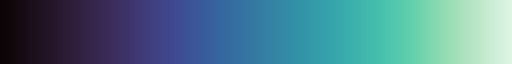

In [8]:
palette_str = 'mako'
palette_str_r = 'mako_r'
palette = sns.color_palette(palette_str)
palette_r = sns.color_palette(palette_str_r)
cmap = sns.color_palette(palette_str, as_cmap=True)
cmap_r = sns.color_palette(palette_str_r, as_cmap=True)
cmap


['#2e1e3b', '#413d7b', '#37659e', '#348fa7', '#40b7ad', '#8bdab2']


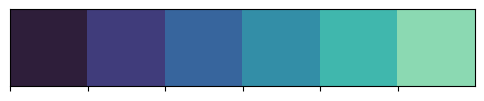

In [9]:
print(palette.as_hex())
sns.palplot(palette)
plt.show()

In [10]:
'''
Setting the CSS
'''
from IPython.display import HTML
style="""
<style>
    div.info { 
        background-color: #40b7ad;
        border-color: #40b7ad; 
        color: white;
        border-radius: 10px;
        width: 800px;
        padding: 2em;
        font-weight: bold;
        font-family: Verdana;
    }
</style>"""
HTML(style)

## Clean the data

In [12]:
# Read the geoencoded data into a standard data frame
# This data was geoencoded using Goole Maps API and Google spreadsheet plugin
# Original data: https://www.kaggle.com/datasets/gauravkumar2525/shark-attacks/data
df = pd.read_csv('geocoded-global-shark-attacks.csv')

# Assign name for columns
columns = (["Date", "Year", "Type", "Country", "Area", "Location", "Activity", "Name", "Gender", "Age", "Fatal", "Time", 
            "Species", "GeoAreaCountry", "GeoLocationAreaCountry", "Latitude", "Longitude"])
df.columns = columns

df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude
0,2023-05-13,2023.0,Unprovoked,AUSTRALIA,South Australia,Elliston,Surfing,Simon Baccanello,M,46,Y,10h10,White shark,"South Australia, AUSTRALIA","Elliston, South Australia, AUSTRALIA",-33.647648,134.89151
1,2023-04-29,2023.0,Unprovoked,AUSTRALIA,Western Australia,"Yallingup, Busselton",Swimming,male,M,NaN,N,11h20,1m shark,"Western Australia, AUSTRALIA","Yallingup, Busselton, Western Australia, AUSTR...",-33.639694,115.02619
2,2022-10-07,2022.0,Unprovoked,AUSTRALIA,Western Australia,Port Hedland,Spearfishing,Robbie Peck,M,38,N,11h30,Bull shark,"Western Australia, AUSTRALIA","Port Hedland, Western Australia, AUSTRALIA",-20.313017,118.57681
3,2021-10-04,2021.0,Unprovoked,USA,Florida,"Fort Pierce State Park, St. Lucie County",Surfing,Truman Van Patrick,M,25.0,N,NaN,NaN,"Florida, USA","Fort Pierce State Park, St. Lucie County, Flor...",27.446976,-80.32606
4,2021-10-03,2021.0,Unprovoked,USA,Florida,"Jensen Beach, Martin County",Swimming,male,M,NaN,N,12h00,NaN,"Florida, USA","Jensen Beach, Martin County, Florida, USA",27.244460,-80.22529


In [13]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1


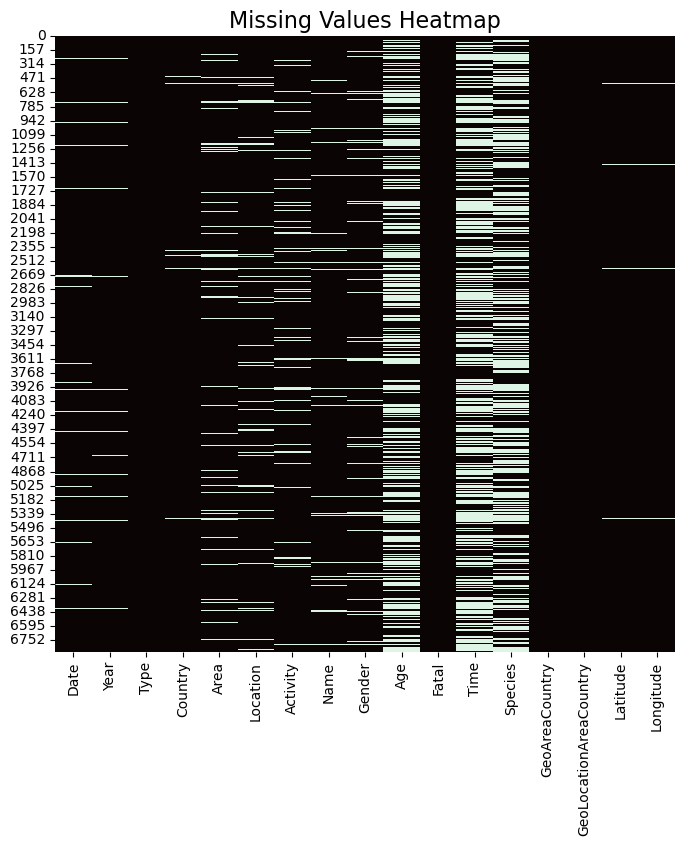

In [14]:
# Visualize missing values as a heatmap
# Source: https://medium.com/@HildaPosada/finding-and-visualizing-missing-data-in-python-using-missingno-and-seaborn-d4cf0452b9e9
plt.figure(figsize=(8, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=palette_str)
plt.title('Missing Values Heatmap', fontsize=16)
plt.savefig('missing-values-heatmap.png', dpi=400)
plt.show()

In [15]:
"""
Cleaning Fatal

The Fatal data is binary either Yes or No.
"""
df["Fatal"] = df["Fatal"].replace("Y",1)
df["Fatal"] = df["Fatal"].replace("y",1)
df["Fatal"] = df["Fatal"].replace("F",1)
df["Fatal"] = df["Fatal"].replace("Y x 2",1)
df["Fatal"] = df["Fatal"].replace("N",0)
df["Fatal"] = df["Fatal"].replace("n",0)
df["Fatal"] = df["Fatal"].replace("Nq",0)  # A single record. Looked up name of victim. She survived.
df["Fatal"] = df["Fatal"].replace("2017.0",0) # Another single record. Looked up name and he survived.
df["Fatal"] = df["Fatal"].replace("UNKNOWN",None)

# Drop the more sparse NA (based on the missing values graph)
df.dropna(subset=["Fatal"], inplace=True)
df.dropna(subset=["Latitude"], inplace=True)
df.dropna(subset=["Longitude"], inplace=True)
df.dropna(subset=["Year"], inplace=True)
df.dropna(subset=["Type"], inplace=True)


"""
Cleaning Date
"""
# Replace NaN with None
df["Date"] = df["Date"].replace("nan", None) 

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Save the Month as this is important. It can map to shark breeding behavior.
df["Month"] = df["Date"].dt.month_name()
df["Month"] = df["Month"].fillna("Unknown")
df["Month"].value_counts()




"""
Cleaning Type
"""
df = df.drop(df[df["Type"] == "Invalid"].index) # Remove invalid record
df = df.drop(df[df["Type"] == "Questionable"].index) # Remove Questionable record
df["Type"] = df["Type"].replace("?","Unknown")
df["Type"] =  df["Type"].fillna("Unknown")
df["Type"] = df["Type"].astype(object)


"""
Cleaning Gender
"""
df["Gender"] = df["Gender"].replace("M x 2","M")
df["Gender"] = df["Gender"].replace("nan", "Unknown") 
df["Gender"] = df["Gender"].replace("N", "Unknown") 
df["Gender"] = df["Gender"].replace(".", "Unknown") 
df["Gender"] = df["Gender"].replace("lli", "Unknown")
df["Gender"] = df["Gender"].replace("", "Unknown")


print("Null: ", df["Gender"].isnull().sum())

df["Gender"] = df["Gender"].fillna("Unknown")
df["Gender"] = df["Gender"].astype(object)


"""
Cleaning Age
"""
def numeric_age(value):
    if not value:
        return None
    
    if value.isdigit():
        value = int(value)

    try:
        value = float(value)
    except ValueError:
        return None
    
    return value


# Everything else with NaN replace with None
df = df.applymap(lambda x: None if pd.isna(x) else x)

df["Age"] = df["Age"].map(numeric_age)


"""
Cleaning Activity
"""
df["Activity"] =  df["Activity"].fillna("Unknown")
others = []

import re

def clean_activity_name(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    
    if re.search("spear", value.lower()):
        return "Spearfishing"
    elif re.search("(fishing|crabbing)", value.lower()):
        return "Fishing"
    elif re.search("(body surfing|body-surfing)", value.lower()):
        return "Body Surfing"
    elif re.search("(snorkeling|snorkling)", value.lower()):
        return "Snorkeling"
    elif re.search("(surf-skiing|surfskiing|surf skiing)", value.lower()):
        return "Surf-skiing"
    elif re.search("kayaking", value.lower()):
        return "Kayaking"
    elif re.search("filming", value.lower()):
        return "Filming"
    elif re.search("(surfing|body boarding|boogie|surf\s+board|surfboard|body-boarding)", value.lower()):
        return "Surfing"
    elif re.search("surf ski", value.lower()):
        return "Surf-skiing"
    elif re.search("(swim|treading)", value.lower()):
        return "Swimming"
    elif re.search("(diving|dived|dive)", value.lower()):
        return "Diving"
    elif re.search("(bathed|bathing)", value.lower()):
        return "Bathing"
    elif re.search("tsunami", value.lower()):
        return "Tsunami"
    elif re.search("outrigger", value.lower()):
        return "Outrigger"
    elif re.search("(kite\s+boarding|kite-boarding|kiteboarding)", value.lower()):
        return "Kite Boarding"
    elif re.search("(foil boarding|foil-boarding|kite foiling)", value.lower()):
        return "Foil Boarding"
    elif re.search("rowing", value.lower()):
        return "Rowing"
    elif re.search("floating", value.lower()):
        return "Floating"
    elif re.search("(sup|paddleboarding|paddleboard|paddle\s+boarding|paddle-boarding)", value.lower()):
        return "SUP"
    elif re.search("(wading|shallows|standing)", value.lower()):
        return "Wading"
    elif re.search("playing", value.lower()):
        return "Playing"
    elif re.search("paddling", value.lower()):
        return "Paddling"
    elif re.search("canoeing", value.lower()):
        return "Canoeing"
    elif re.search("fell", value.lower()):
        return "Fell"
    elif re.search("jumping", value.lower()):
        return "Jumping"
    elif re.search("walking", value.lower()):
        return "Walking"
    elif re.search("shark", value.lower()):
        return "Direct Contact"
    elif re.search("(boat accident|capsize|sunk|sink|sank|overboard|adrift|ship|explosion|destroyer|freighter|torpedo|shipwrecked|wrecked|wreck|swamped|founder|sea disaster|ship wreck)", value.lower()):
        return "Boat Accident"
    elif re.search("(airline|aircraft|crash|plane)", value.lower()):
        return "Air Accident"
    else:
        others.append(value)
        return value
        

df["Activity"] = df["Activity"].apply(lambda x: " ".join(x.split())) # strip extra whitespace from string
df["Activity"] = df["Activity"].map(clean_activity_name)
df["Activity"] = df["Activity"].astype(object)


"""
Cleaning Country
"""
df["Country"] = df["Country"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Country"] = df["Country"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Country"] = df["Country"].astype(object)


"""
Cleaning Area
"""
df["Area"] = df["Area"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Area"] = df["Area"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Area"] = df["Area"].astype(object)



"""
Location
"""
df["Location"] = df["Location"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Location"] = df["Location"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())



"""
Cleaning Species
"""
others = []
def clean_species(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    # Note: Order of conditional matters
    if re.search("sand", value.lower()):
        return "Sand Shark"
    elif re.search("(raggedtooth| ragged tooth)", value.lower()):
        return "Raggedtooth Shark"
    elif re.search("(bull|zambezi|zambesi|leucas)", value.lower()):
        return "Bull Shark"
    elif re.search("lemon", value.lower()):
        return "Lemon Shark"
    elif re.search("thresher", value.lower()):
        return "Thresher Shark"
    elif re.search("nurse", value.lower()):
        return "Nurse Shark"
    elif re.search("(hammerhead|hammer head)", value.lower()):
        return "Hammerhead Shark"
    elif re.search("(blacktip|black tip)", value.lower()):
        return "Blacktip Shark"
    elif re.search("(copper|bronze|whaler|narrowtooth)", value.lower()):
        return "Copper Shark"
    elif re.search("(whale|while shark)", value.lower()):
        return "Whale Shark"
    elif re.search("mako", value.lower()):
        return "Mako Shark"
    elif re.search("(leopard|leapord)", value.lower()):
        return "Leopard Shark"
    elif re.search("blue", value.lower()):
        return "Blue Shark"
    elif re.search("spinner", value.lower()):
        return "Spinner Shark"
    elif re.search("wobbegong", value.lower()):
        return "Wobbegong Shark"
    elif re.search("carpet", value.lower()):
        return "Carpet Shark"
    elif re.search("reef", value.lower()):
        return "Reef Shark" 
    elif re.search("(dusky|c. obscurus|carcharhinus obscurus)", value.lower()):
        return "Dusky Shark"   
    elif re.search("angel", value.lower()):
        return "Angel Shark" 
    elif re.search("shovelnose", value.lower()):
        return "Shovelnose Shark" 
    elif re.search("sharpnose", value.lower()):
        return "Sharpnose Shark" 
    elif re.search("(sevengill|seven-gill|seven gill)", value.lower()):
        return "Sevengill Shark"
    elif re.search("(galapagos|galapagensis)", value.lower()):
        return "Galapagos Shark"
    elif re.search("(grey|gray|Carcharhinus)", value.lower()):
        return "Gray Shark"
    elif re.search("(whitetip| white tip)", value.lower()):
        return "Whitetip Shark"
    elif re.search("(white|great)", value.lower()):
        return "White Shark"
    elif re.search("tiger", value.lower()):
        return "Tiger Shark"
    else:
        others.append(value)
        return value


df["Species"] = df["Species"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Species"] = df["Species"].map(clean_species)
df["Species"] = df["Species"].astype(object)
df["Species"] = df["Species"].apply(lambda x: "Unknown" if pd.isna(x) else x)
# Leaving Species N/A as Unknown because there should be a correlation between fatality and no report / sighting of species

# Final cleaning
df["Area"] =  df["Area"].fillna("Unknown")




Null:  452


In [16]:
"""
Create the Geohashes
"""
# Convert the geo data to a GeoDataFrame
# EPSG:4326 is the widely used code for the WGS 84 geographic coordinate system
loc_crs = {'init': 'epsg:4326'}
loc_geom = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
geo_df = gpd.GeoDataFrame(df, crs=loc_crs, geometry=loc_geom)

# Geohash can determine proximity but fails if point is across geohash grid boundary
# Points near 180 degress meridian may have very different Geohashes
# Precision decreases near the polls
# Cells have different physical areas at different latitudes

"""
Geohash precision:
1   5,009.4km x 4,992.6km
2   1,252.3km x 624.1km
3   156.5km x 156km
4   39.1km x 19.5km
5   4.9km x 4.9km
6   1.2km x 609.4m
7   152.9m x 152.4m
8   38.2m x 19m
9   4.8m x 4.8m
10  1.2m x 59.5cm
11  14.9cm x 14.9cm
12  3.7cm x 1.9cm 
"""
# Precision 8 yielded best initial scores
# But we can use Geohashes to create a sort of bounding box of different sizes
geo_df['Geohash P4'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=4), axis=1)
geo_df['Geohash P5'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=5), axis=1)
geo_df['Geohash P6'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=6), axis=1)
geo_df['Geohash P7'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=7), axis=1)
geo_df['Geohash P8'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=8), axis=1)
geo_df['Geohash P9'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=9), axis=1)


def get_hemisphere(latitude):
    """
    Determines the hemisphere (Northern or Southern) based on latitude.

    Args:
        latitude (float): The latitude of the geographic point.

    Returns:
        str: "Northern" if latitude > 0,
             "Southern" if latitude < 0,
             "Equator" if latitude == 0.
    """
    if latitude > 0:
        return "Northern"
    elif latitude < 0:
        return "Southern"
    else:
        return "Equator"

geo_df['Hemisphere'] = df.apply(lambda row: get_hemisphere(row['Latitude']), axis=1)

geo_df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude,Month,geometry,Geohash P4,Geohash P5,Geohash P6,Geohash P7,Geohash P8,Geohash P9,Hemisphere
0,2023-05-13,2023.0,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,ELLISTON,Surfing,Simon Baccanello,M,46.0,1,10h10,White Shark,"South Australia, AUSTRALIA","Elliston, South Australia, AUSTRALIA",-33.647648,134.89151,May,POINT (134.89151 -33.64765),qfpb,qfpbt,qfpbtd,qfpbtd8,qfpbtd8u,qfpbtd8up,Southern
1,2023-04-29,2023.0,Unprovoked,AUSTRALIA,WESTERN AUSTRALIA,"YALLINGUP, BUSSELTON",Swimming,male,M,NaN,0,11h20,1m shark,"Western Australia, AUSTRALIA","Yallingup, Busselton, Western Australia, AUSTR...",-33.639694,115.02619,April,POINT (115.02619 -33.63969),qd1b,qd1b9,qd1b9k,qd1b9kp,qd1b9kpd,qd1b9kpd8,Southern
2,2022-10-07,2022.0,Unprovoked,AUSTRALIA,WESTERN AUSTRALIA,PORT HEDLAND,Spearfishing,Robbie Peck,M,38.0,0,11h30,Bull Shark,"Western Australia, AUSTRALIA","Port Hedland, Western Australia, AUSTRALIA",-20.313017,118.57681,October,POINT (118.57681 -20.31302),qskk,qskk6,qskk6q,qskk6q0,qskk6q0u,qskk6q0up,Southern
3,2021-10-04,2021.0,Unprovoked,USA,FLORIDA,"FORT PIERCE STATE PARK, ST. LUCIE COUNTY",Surfing,Truman Van Patrick,M,25.0,0,None,Unknown,"Florida, USA","Fort Pierce State Park, St. Lucie County, Flor...",27.446976,-80.32606,October,POINT (-80.32606 27.44698),dhyu,dhyuh,dhyuhh,dhyuhhs,dhyuhhs6,dhyuhhs65,Northern
4,2021-10-03,2021.0,Unprovoked,USA,FLORIDA,"JENSEN BEACH, MARTIN COUNTY",Swimming,male,M,NaN,0,12h00,Unknown,"Florida, USA","Jensen Beach, Martin County, Florida, USA",27.244460,-80.22529,October,POINT (-80.22529 27.24446),dhyf,dhyfy,dhyfyr,dhyfyrt,dhyfyrtw,dhyfyrtwr,Northern


## Explore the Data
Let's plot the data to explore patterns.

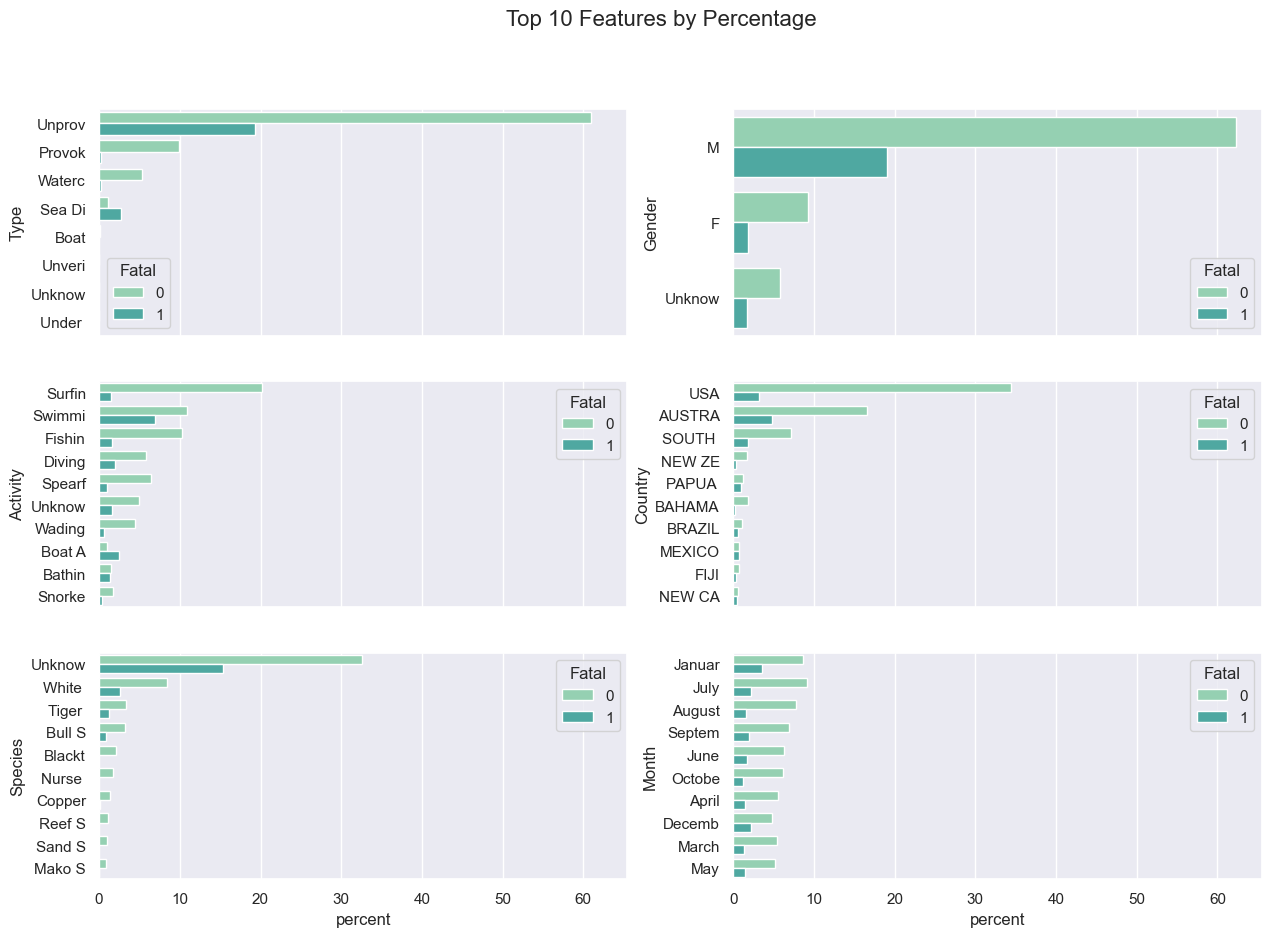

In [18]:
"""
Top 10
"""
def truncator(value):
    return value[0:6]
    
def top_10_count_plot(df, cols_list):
    ncols = 2
    nrows = int(len(cols_list) / 2)
    if len(cols_list)%2 > 0:
        nrows += 1

    
    sns.set()
    sns.set_palette(palette_r)
    figure, axes = plt.subplots(nrows, ncols, sharex=True, figsize=(15,10))
    figure.suptitle("Top 10 Features by Percentage", fontsize=16)

    irow = 1
    icol = 1
    for col in cols_list:
        sns.countplot(ax=axes[irow-1,icol-1],
                      y=col, 
                      data=df, 
                      hue="Fatal", 
                      stat="percent", 
                      formatter=truncator, 
                      order=df[col].value_counts().iloc[:10].index)
        # Set next row, col
        if icol == 2:
            irow += 1
            icol = 1
        else:
            icol += 1

    plt.savefig('top10-percentages-hue-fatal.png', dpi=400)
    plt.show()
    
top_10_count_plot(geo_df, ["Type", "Gender", "Activity", "Country", "Species", "Month"])

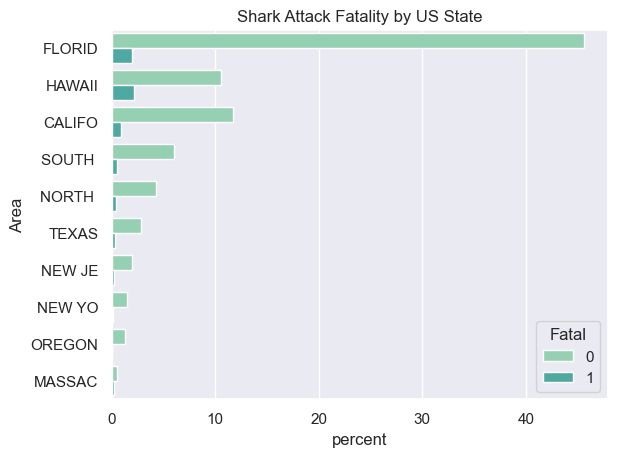

In [19]:
"""
By US State
"""
usa = geo_df[(geo_df["Country"] == "USA") & (geo_df["Fatal"] != "Unknown")] 

sns.set_palette(palette_r)
sns.countplot(y="Area", 
              data=usa, 
              hue="Fatal", 
              stat="percent", 
              formatter=truncator, 
              order=usa["Area"].value_counts().iloc[:10].index)
plt.title("Shark Attack Fatality by US State")
plt.show()


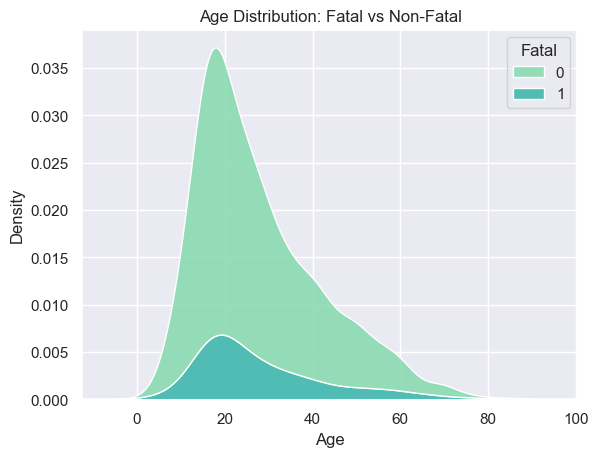

In [21]:
"""
Age
"""
sns.set_palette(palette_r)
sns.kdeplot(data=geo_df, x="Age", hue="Fatal", alpha=0.9, zorder=3, multiple="stack")   
plt.title("Age Distribution: Fatal vs Non-Fatal")
plt.savefig('age-kdeplot-with-fatal.png', dpi=400)
plt.show()

In [23]:
"""
Setup shared config for chart display
"""
fatal = geo_df[geo_df["Fatal"] == 1]
nfatal = geo_df[geo_df["Fatal"] == 0]

background_color = "#f6f6f6"
fatal_color = "#c9533e"
nfatal_color = "#495b8d"


### Time of the Year - Northen Hemisphere
Can we see a pattern with fatal vs non-fatal for different times of the year?

<Figure size 1000x3000 with 0 Axes>

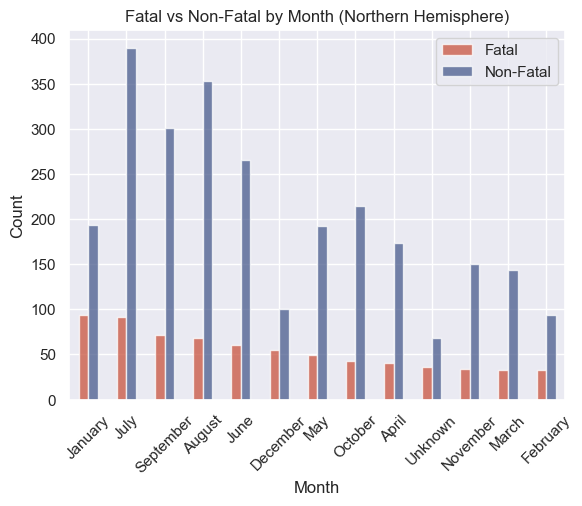

In [25]:
feature = "Month"


fatal_northern = fatal[fatal["Hemisphere"] == 'Northern']
nfatal_northern = nfatal[nfatal["Hemisphere"] == 'Northern']

positive_northern = pd.DataFrame(fatal_northern[feature].value_counts(sort=True))

negative_northern = pd.DataFrame(nfatal_northern[feature].value_counts(sort=True))


by_month_northern = pd.concat([positive_northern["count"], negative_northern["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)



plt.figure(figsize=(10, 30))
by_month_northern.plot(kind='bar', alpha=0.75, rot=45, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Month (Northern Hemisphere)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.savefig('by-month-northern.png', dpi=400, bbox_inches='tight') 
plt.show()



### Time of the Year - Southern Hemisphere
Can we see a pattern with fatal vs non-fatal for different times of the year?

<Figure size 1000x3000 with 0 Axes>

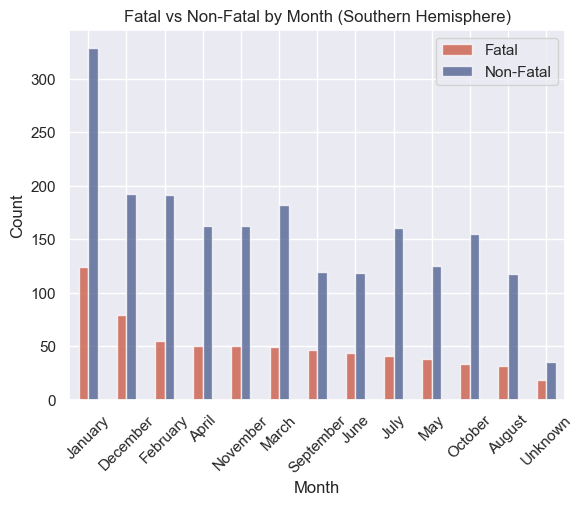

In [28]:
feature = "Month"

fatal_southern = fatal[fatal["Hemisphere"] == 'Southern']
nfatal_southern = nfatal[nfatal["Hemisphere"] == 'Southern']

positive_southern = pd.DataFrame(fatal_southern[feature].value_counts(sort=True))

negative_southern = pd.DataFrame(nfatal_southern[feature].value_counts(sort=True))

by_month_southern = pd.concat([positive_southern["count"], negative_southern["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)



plt.figure(figsize=(10, 30))
by_month_southern.plot(kind='bar', alpha=0.75, rot=45, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Month (Southern Hemisphere)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.savefig('by-month-southern.png', dpi=400, bbox_inches='tight') 
plt.show()


### Attacks by Activity

<Figure size 1500x600 with 0 Axes>

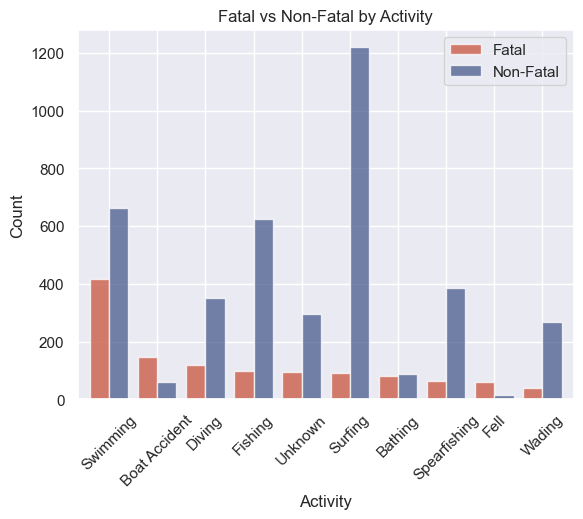

In [31]:
feature = "Activity"


positive = pd.DataFrame(fatal[feature].value_counts(sort=True))
negative = pd.DataFrame(nfatal[feature].value_counts(sort=True))

by_activity = pd.concat([positive["count"], negative["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)


plt.figure(figsize=(15,6))
by_activity.head(10).plot(kind='bar', alpha=0.75, rot=45, width=0.8, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Activity')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.savefig('by-activity.png', dpi=400, bbox_inches='tight') 
plt.show()


### Attacks by Species

<Figure size 1500x600 with 0 Axes>

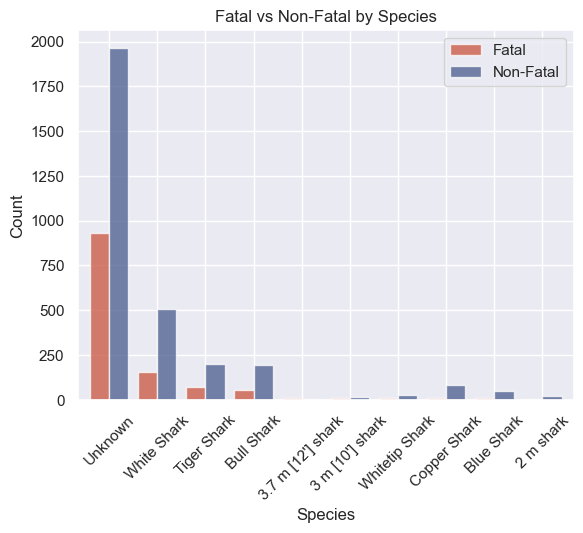

In [34]:
feature = "Species"


positive = pd.DataFrame(fatal[feature].value_counts(sort=True))
negative = pd.DataFrame(nfatal[feature].value_counts(sort=True))

by_species = pd.concat([positive["count"], negative["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)


plt.figure(figsize=(15,6))
by_species.head(10).plot(kind='bar', alpha=0.75, rot=45, width=0.8, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.savefig('by-species.png', dpi=400, bbox_inches='tight') 
plt.show()


### Attacks by Gender

<Figure size 1000x600 with 0 Axes>

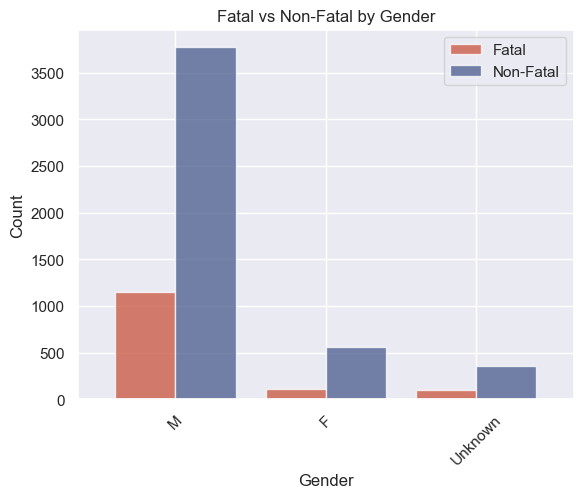

In [36]:
feature = "Gender"


positive = pd.DataFrame(fatal[feature].value_counts(sort=True))
negative = pd.DataFrame(nfatal[feature].value_counts(sort=True))

by_gender = pd.concat([positive["count"], negative["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)


plt.figure(figsize=(10,6))
by_gender.head(10).plot(kind='bar', alpha=0.75, rot=45, width=0.8, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('by-gender.png', dpi=400, bbox_inches='tight') 
plt.show()


### Attacks by Country

<Figure size 1500x600 with 0 Axes>

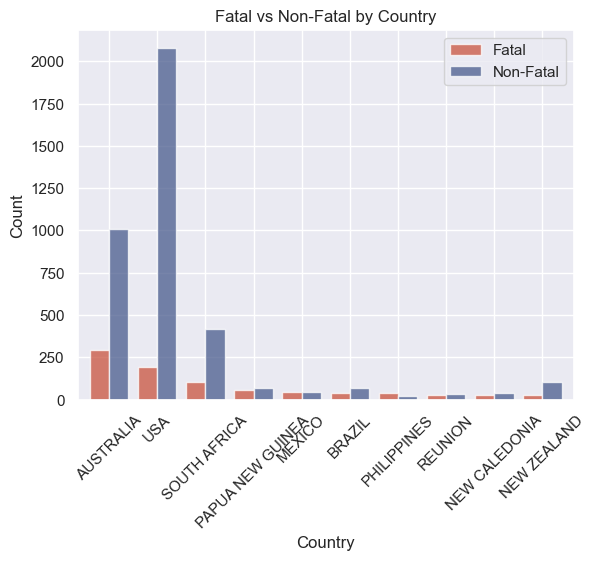

In [38]:
feature = "Country"

positive = pd.DataFrame(fatal[feature].value_counts(sort=True))
negative = pd.DataFrame(nfatal[feature].value_counts(sort=True))

by_country = pd.concat([positive["count"], negative["count"]], keys=['Fatal', 'Non-Fatal'], axis=1)


plt.figure(figsize=(15,6))
by_country.head(10).plot(kind='bar', alpha=0.75, rot=45, width=0.8, color=['#c9533e', '#495b8d'], title='Fatal vs Non-Fatal by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.savefig('by-country.png', dpi=400, bbox_inches='tight') 
plt.show()

### Global Shark Attacks Map
Let's plot the Geo points onto a world map of fatal vs non-fatal.

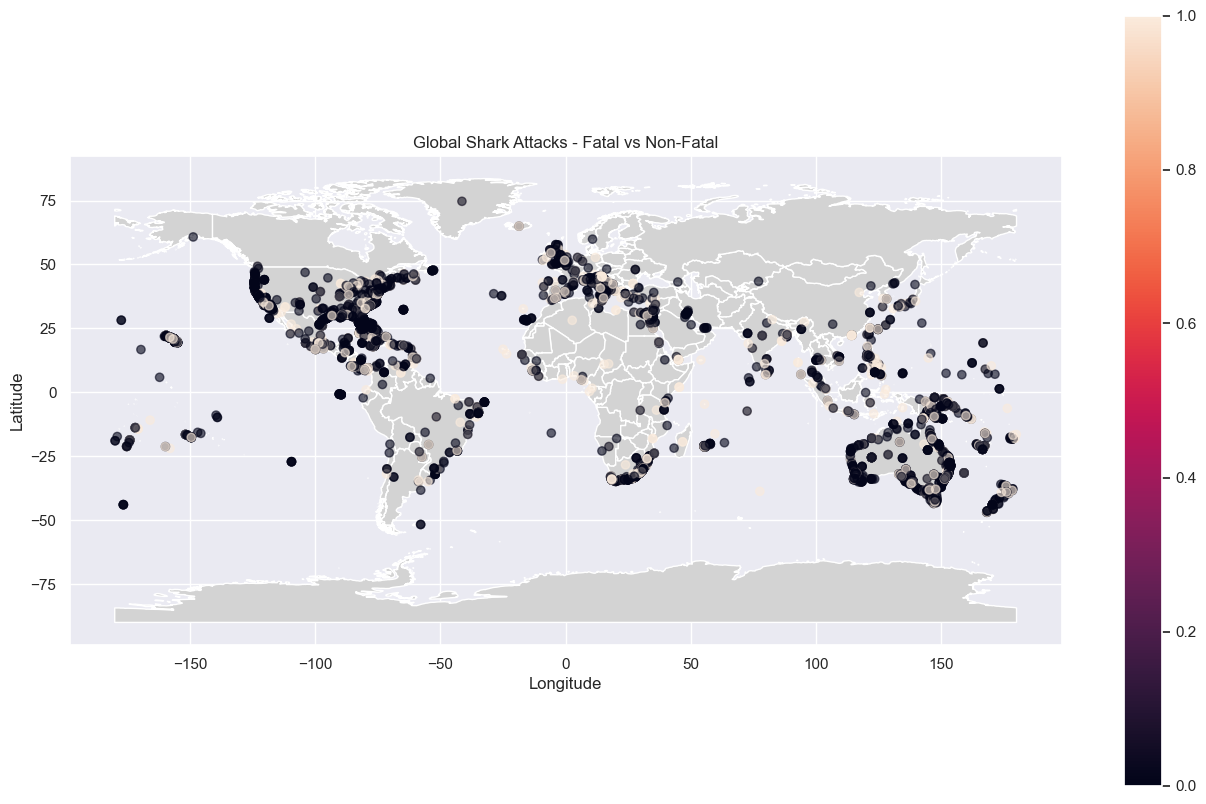

In [41]:
"""
Plot the Geo Points
"""
worldmap = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
fig, ax = plt.subplots(figsize=(16, 10))
worldmap.plot(color="lightgrey", ax=ax, legend=True)

geo_points = geo_df[["Fatal", "geometry"]].copy(deep=True)

geo_points.plot(ax=ax, column='Fatal',  legend=True, alpha=0.6)
plt.title("Global Shark Attacks - Fatal vs Non-Fatal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig('global-map.png', dpi=400, bbox_inches='tight') 
plt.show()



In [42]:
"""
Choosing median Age instead of mean because of outlier values.
"""
geo_df["Age"] = geo_df["Age"].fillna(geo_df["Age"].median()) # Apply median to fill NA

## Model Bakeoff

In [44]:
"""
Select the features and target

- There is a strong correlation between Area, Country, Location and Geo data
- I omitted Location as it resulted in worse performance
- We're selecting 2 Geohashes per row - precision 8 and precision 5.
- I omitted Time because there is so many missing, it would reduce the dataset to 2k from 6k
- It may be worth exploring time (thus reducing the dataset) using a sin/cos function to track cyclical hours
- I'm curious if fatality can be linked to hospital proximity and holidays/vacations as well as shifts (time of day) 
  ... if a hospital is near the attack
"""

X = geo_df[["Activity",  "Age", "Area",  "Country", "Gender", "Month", "Species", "Year", "Type", "Geohash P8", "Geohash P5", "Hemisphere" ]]
print(X.info())

numeric_features = [ "Age", "Year"]


onehot_features = ["Activity",  "Month",  "Type",  "Hemisphere", "Area", "Country", "Species"]
target_features = ["Geohash P8", "Geohash P5" ]
ordinal_features = ["Gender"]

y = geo_df[["Fatal"]]


print(geo_df.isnull().sum())
geo_df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 6053 entries, 0 to 6884
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Activity    6053 non-null   object 
 1   Age         6053 non-null   float64
 2   Area        6053 non-null   object 
 3   Country     6053 non-null   object 
 4   Gender      6053 non-null   object 
 5   Month       6053 non-null   object 
 6   Species     6053 non-null   object 
 7   Year        6053 non-null   float64
 8   Type        6053 non-null   object 
 9   Geohash P8  6053 non-null   object 
 10  Geohash P5  6053 non-null   object 
 11  Hemisphere  6053 non-null   object 
dtypes: float64(2), object(10)
memory usage: 614.8+ KB
None
Date                       157
Year                         0
Type                         0
Country                      0
Area                         0
Location                     0
Activity                     0
Name                       145
Gender          

(6053, 26)

In [45]:
"""
Shared data using StandardScaler()
We will use to tune each model
"""
preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_features),
                      ('ordinal', OrdinalEncoder(), ordinal_features),
                      ('target', TargetEncoder(
                          smoothing=5,
                          handle_unknown='value',  # unseen categories handled gracefully
                          handle_missing='value'
                      ), target_features)])


# With TargetEncoder, to not leak data, must split the data first            
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Be sure to use Pipeline to make predictions from test data. To scale test data properly.

# Handle fatal imbalance
#
# fatal_0:  3812
# fatal_1:  1160
# ratio:  3.286206896551724
count_fatal_0 = y_train.value_counts()[0]
count_fatal_1 = y_train.value_counts()[1]
ratio = count_fatal_0/count_fatal_1

## KNN

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [48]:
"""
We are fitting models for different values of k. We are then finding accuracy for each model 
and storing it in scores_list.
"""

k_range = range(1, 20)
scores_list = []
for k in k_range:
    knn = Pipeline(steps = [('pre', preprocessor),('KNN',KNeighborsClassifier(n_neighbors=k))])
 
    knn.fit(x_train, np.ravel(y_train))
    y_pred = knn.predict(x_test)
    scores_list.append(metrics.accuracy_score(y_test, y_pred))

# We are plotting accuracy for different values of k
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(k_range, scores_list)
plt.xlabel("Value of k in KNN")
plt.ylabel("Test Accuracy")
plt.savefig('knn-accuracy.png', dpi=400, bbox_inches='tight')

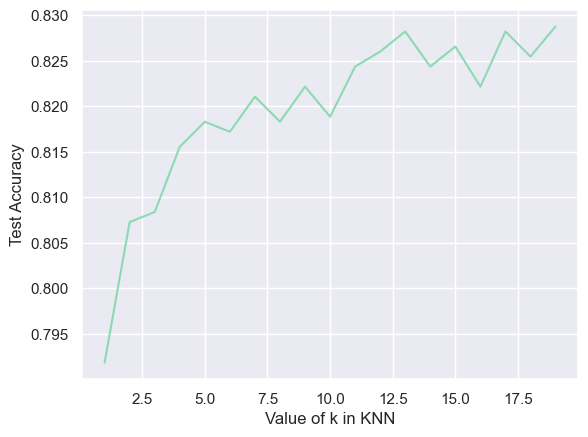

In [49]:
plt.show()

In [50]:
knn = Pipeline(steps = [('pre', preprocessor),('KNN',KNeighborsClassifier(n_neighbors=13))])

knn.fit(x_train, np.ravel(y_train))

y_pred = knn.predict(x_test)
knn_pred = y_pred
print(metrics.accuracy_score(y_test, y_pred))

0.8281938325991189


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = knn.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)


print("AUC_ROC", roc_auc_score(y_test, y_pred_proba))

AUC_ROC 0.8613272546234403


In [52]:
print(classification_report(y_test,y_pred))
knn_pred = y_pred

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1408
           1       0.68      0.45      0.54       408

    accuracy                           0.83      1816
   macro avg       0.77      0.69      0.72      1816
weighted avg       0.81      0.83      0.81      1816



## Tuning Logistic Regression
Let's tune the logistic regression model to get the best performance.

In [ ]:
penalty = ['l1','l2']
C = [0.01, 0.1, 1, 10, 100] 
solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

log_param_grid = {'LR__penalty': penalty, 
                  'LR__C': C,
                  'LR__solver': solvers }

logreg = Pipeline(steps = [('pre', preprocessor),('LR', LogisticRegression(class_weight={0:1, 1:ratio}, random_state=42))])

grid = GridSearchCV(logreg,log_param_grid)

grid.fit(x_train,y_train)

In [ ]:
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_}")
print(f"Test set score: {grid.score(x_test, y_test)}")

In [ ]:
"""
Using best params:
"""

logreg_pipeline = Pipeline(steps = [('pre', preprocessor),('LR', LogisticRegression(class_weight={0:1, 1:ratio}, C=1,penalty='l2',solver='newton-cg', random_state=42))])
logreg_pipeline.fit(x_train,y_train)
logreg_tuned_pred   = logreg_pipeline.predict(x_test)

print(classification_report(y_test,logreg_tuned_pred))

## Tuning SVM

In [ ]:
parameters = {'SVM__kernel':["rbf"],
              'SVM__C':[0.1, 1, 10, 100],
              'SVM__gamma': [1, 0.6, 0.4, 0.3, 0.1]}

svm = Pipeline(steps = [('pre', preprocessor),('SVM', SVC(class_weight={0:1, 1:ratio}, random_state=42))])

grid = GridSearchCV(svm, parameters, cv=5, verbose=3, n_jobs=-1)
grid.fit(x_train,y_train)

In [ ]:
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_}")
print(f"Test set score: {grid.score(x_test, y_test)}")

In [ ]:
svm_pipeline = Pipeline(steps = [('pre', preprocessor), ('SVM',SVC(class_weight={0:1, 1:ratio}, C=1, gamma=0.3, kernel='rbf',random_state=42))])

svm_pipeline.fit(x_train,y_train)

svm_tuned_pred   = svm_pipeline.predict(x_test)

print(classification_report(y_test,svm_tuned_pred))

## Tuning Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = Pipeline(steps = [('pre', preprocessor), ('DT',DecisionTreeClassifier(criterion="entropy", min_samples_leaf=5))])
dtree.fit(x_train, y_train)  

dtree_tuned_predict = dtree.predict(x_test)
print(classification_report(y_test,dtree_tuned_predict))

## Model Performance Results

In [ ]:
"""
Setup the data frames to compare results
"""


svm_df = pd.DataFrame(data=[f1_score(y_test,svm_tuned_pred),accuracy_score(y_test, svm_tuned_pred), recall_score(y_test, svm_tuned_pred),
                   precision_score(y_test, svm_tuned_pred), roc_auc_score(y_test, svm_tuned_pred)], 
             columns=['SVM Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

lr_df = pd.DataFrame(data=[f1_score(y_test,logreg_tuned_pred),accuracy_score(y_test, logreg_tuned_pred), recall_score(y_test, logreg_tuned_pred),
                   precision_score(y_test, logreg_tuned_pred), roc_auc_score(y_test, logreg_tuned_pred)], 
             columns=['Logistic Regression Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

knn_df = pd.DataFrame(data=[f1_score(y_test,knn_pred),accuracy_score(y_test, knn_pred), recall_score(y_test, knn_pred),
                   precision_score(y_test, knn_pred), roc_auc_score(y_test, knn_pred)], 
             columns=['KNN'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])
dtree_df = pd.DataFrame(data=[f1_score(y_test,dtree_tuned_predict),accuracy_score(y_test, dtree_tuned_predict), recall_score(y_test, dtree_tuned_predict),
                   precision_score(y_test, dtree_tuned_predict), roc_auc_score(y_test,dtree_tuned_predict)], 
             columns=['Decision Tree'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])

In [ ]:
"""
Create the matrix of results
"""
df_models = round(pd.concat([svm_df,lr_df, knn_df, dtree_df], axis=1),3)

background_color = "#fbfbfb"
sns.set()
sns.set_palette(palette)

fig = plt.figure(figsize=(15,13)) # create figure
gs = fig.add_gridspec(5, 2)
gs.update(wspace=0.1, hspace=0.5)
ax0 = fig.add_subplot(gs[0, :])

sns.heatmap(df_models.T, cmap=cmap,annot=True,fmt=".1%",vmin=0,vmax=0.95, linewidths=2.5,cbar=False,ax=ax0,annot_kws={"fontsize":12})
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color) 

ax0.text(0,-1.15,'Model Results',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.tick_params(axis=u'both', which=u'both',length=0)

plt.savefig('model-results-matrix.png', dpi=400)
plt.show()